## Dataset analysis

In [2]:
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


# 1. Load dataset
def load_dataset(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        first_char = f.read(1)
        f.seek(0)

        if first_char == "[":
            data = json.load(f)
        else:
            for line in f:
                data.append(json.loads(line))

    return data


# 2. Extract descriptions
def extract_descriptions(data):
    descriptions = []
    ids = []

    for item in data:
        desc = item.get("description", "").strip()
        if desc:
            descriptions.append(desc)
            ids.append(item.get("id"))

    return ids, descriptions


# 3. Compute embeddings
def compute_embeddings(desc_a, desc_b, model_name="all-MiniLM-L6-v2"):
    model = SentenceTransformer(model_name)
    emb_a = model.encode(desc_a, show_progress_bar=True)
    emb_b = model.encode(desc_b, show_progress_bar=True)
    return emb_a, emb_b


# 4. Compute similarity matrix
def compute_similarity_matrix(emb_a, emb_b):
    return cosine_similarity(emb_a, emb_b)


# 5. Get top-k cross-dataset matches
def get_top_k_cross(ids_a, ids_b, sim_matrix, k=5):
    results = []

    for i in range(len(ids_a)):
        similarities = sim_matrix[i]
        sorted_idx = np.argsort(similarities)[::-1]

        top_matches = []
        for j in sorted_idx[:k]:
            top_matches.append((ids_b[j], similarities[j]))

        results.append({
            "source_id": ids_a[i],
            "top_k_similar": top_matches
        })

    return results


# 6. Save results
def save_cross_results(sim_matrix, ids_a, ids_b, top_k_results, output_prefix="../results/cross"):
    # Full matrix
    df = pd.DataFrame(sim_matrix, index=ids_a, columns=ids_b)
    df.to_csv(f"{output_prefix}_matrix.csv")

    # Top-K
    rows = []
    for item in top_k_results:
        for match_id, score in item["top_k_similar"]:
            rows.append({
                "source_id": item["source_id"],
                "target_id": match_id,
                "similarity": score
            })

    pd.DataFrame(rows).to_csv(f"{output_prefix}_topk.csv", index=False)


# 7. Main pipeline
def main(dataset_a_path, dataset_b_path):
    print("Loading datasets...")
    data_a = load_dataset(dataset_a_path)
    data_b = load_dataset(dataset_b_path)

    print("Extracting descriptions...")
    ids_a, desc_a = extract_descriptions(data_a)
    ids_b, desc_b = extract_descriptions(data_b)

    print(f"A: {len(ids_a)} entries | B: {len(ids_b)} entries")

    print("Computing embeddings...")
    emb_a, emb_b = compute_embeddings(desc_a, desc_b)

    print("Computing similarity matrix...")
    sim_matrix = compute_similarity_matrix(emb_a, emb_b)

    print("Extracting top-k similarities...")
    top_k_results = get_top_k_cross(ids_a, ids_b, sim_matrix, k=5)

    print("Saving results...")
    save_cross_results(sim_matrix, ids_a, ids_b, top_k_results)

    print("Done!")


if __name__ == "__main__":
    main(
        "../results/bigcodebench_clones_test.json",
        "../results/bigcodebench_clones_train.json"
    )


Loading datasets...
Extracting descriptions...
A: 173 entries | B: 689 entries
Computing embeddings...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Computing similarity matrix...
Extracting top-k similarities...
Saving results...
Done!



=== Global Statistics ===
mean: 0.1591
std: 0.1403
min: -0.2541
max: 1.0000
median: 0.1444


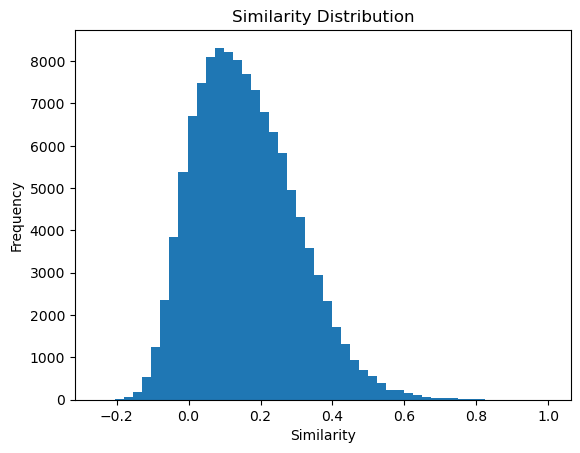


=== Per-entry Summary ===
       best_similarity  avg_similarity
count       173.000000      173.000000
mean          0.658101        0.159105
std           0.103994        0.057209
min           0.392069        0.008658
25%           0.583493        0.123632
50%           0.659969        0.165097
75%           0.727254        0.200921
max           1.000000        0.259481

=== Coverage @ 0.6 ===
Covered: 117/173
Coverage: 0.6763

=== Ambiguity @ 0.6 ===
Ambiguous entries: 86
Ratio: 0.4971

=== Novelty @ 0.4 ===
Novel entries: 1/173
Ratio: 0.0058

Analysis complete.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# 1. Load matrix

def load_matrix(path):
    df = pd.read_csv(path, index_col=0)
    return df



# 2. Global statistics

def global_stats(matrix):
    values = matrix.values.flatten()

    stats = {
        "mean": np.mean(values),
        "std": np.std(values),
        "min": np.min(values),
        "max": np.max(values),
        "median": np.median(values)
    }

    print("\n=== Global Statistics ===")
    for k, v in stats.items():
        print(f"{k}: {v:.4f}")

    return stats



# 3. Similarity distribution

def plot_distribution(matrix):
    values = matrix.values.flatten()

    plt.hist(values, bins=50)
    plt.xlabel("Similarity")
    plt.ylabel("Frequency")
    plt.title("Similarity Distribution")
    plt.show()



# 4. Per-entry analysis (A → B)

def per_entry_analysis(matrix):
    results = []

    for idx, row in matrix.iterrows():
        values = row.values

        best_idx = np.argmax(values)
        best_score = values[best_idx]

        avg_score = np.mean(values)

        results.append({
            "source_id": idx,
            "best_target": matrix.columns[best_idx],
            "best_similarity": best_score,
            "avg_similarity": avg_score
        })

    df = pd.DataFrame(results)

    print("\n=== Per-entry Summary ===")
    print(df.describe())

    return df



# 5. Coverage analysis

def coverage_analysis(matrix, threshold=0.6):
    max_sim = matrix.max(axis=1)

    covered = (max_sim >= threshold).sum()
    total = len(max_sim)

    coverage = covered / total

    print(f"\n=== Coverage @ {threshold} ===")
    print(f"Covered: {covered}/{total}")
    print(f"Coverage: {coverage:.4f}")

    return coverage



# 6. Ambiguity analysis

def ambiguity_analysis(matrix, threshold=0.6):
    ambiguous = 0

    for _, row in matrix.iterrows():
        strong_matches = (row.values >= threshold).sum()
        if strong_matches > 1:
            ambiguous += 1

    ratio = ambiguous / len(matrix)

    print(f"\n=== Ambiguity @ {threshold} ===")
    print(f"Ambiguous entries: {ambiguous}")
    print(f"Ratio: {ratio:.4f}")

    return ratio



# 7. Novelty analysis

def novelty_analysis(matrix, threshold=0.4):
    max_sim = matrix.max(axis=1)

    novel = (max_sim < threshold).sum()
    total = len(max_sim)

    print(f"\n=== Novelty @ {threshold} ===")
    print(f"Novel entries: {novel}/{total}")
    print(f"Ratio: {novel/total:.4f}")

    return novel / total



# 8. Save per-entry results

def save_summary(df, path="analysis_summary.csv"):
    df.to_csv(path, index=False)



# 9. Main

def main(matrix_path):
    matrix = load_matrix(matrix_path)

    global_stats(matrix)
    plot_distribution(matrix)

    per_entry_df = per_entry_analysis(matrix)
    save_summary(per_entry_df)

    coverage_analysis(matrix, threshold=0.6)
    ambiguity_analysis(matrix, threshold=0.6)
    novelty_analysis(matrix, threshold=0.4)

    print("\nAnalysis complete.")


if __name__ == "__main__":
    main("../results/cross_matrix.csv")

## Tests analysis

In [4]:
import json
import pandas as pd
import re


# 1. Load dataset

def load_dataset(path):
    with open(path, "r", encoding="utf-8") as f:
        first_char = f.read(1)
        f.seek(0)
        if first_char == "[":
            return json.load(f)
        else:
            data = {}
            for line in f:
                data.update(json.loads(line))
            return data


# 2. Count test functions per entry

def count_tests_per_entry(data):
    rows = []

    for entry in data:
        entry_id = entry.get("id")
        test_blocks = entry.get("test", [])
        num_tests = 0

        for block in test_blocks:
            # Count lines that define a test function: def test_
            num_tests += len(re.findall(r"^\s*def\s+test_", block, flags=re.MULTILINE))

        rows.append({
            "id": entry_id,
            "num_tests": num_tests
        })

    return pd.DataFrame(rows)


# 3. Save to CSV

def save_to_csv(df, path="test_counts.csv"):
    df.to_csv(path, index=False)


# 4. Main

def main(input_path, output_path="test_counts.csv"):
    print("Loading dataset...")
    data = load_dataset(input_path)

    print("Counting test functions per entry...")
    df = count_tests_per_entry(data)

    print(f"Total entries processed: {len(df)}")

    print("Saving CSV...")
    save_to_csv(df, output_path)

    print("Done!")

if __name__ == "__main__":
    main("../dataset/bigcodebench_normalized_filtered.json", "../results/test_counts.csv")

Loading dataset...


Counting test functions per entry...
Total entries processed: 927
Saving CSV...
Done!



=== Statistics ===
total_entries: 927
min_tests: 3
max_tests: 15
mean_tests: 5.6375404530744335
median_tests: 5.0
std_tests: 1.3430139182826422


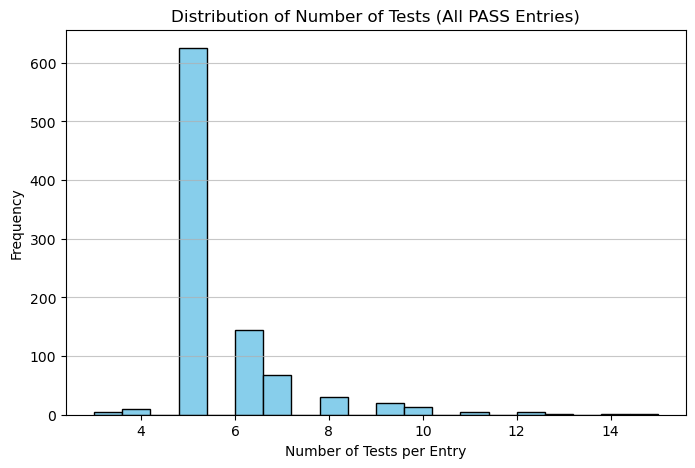

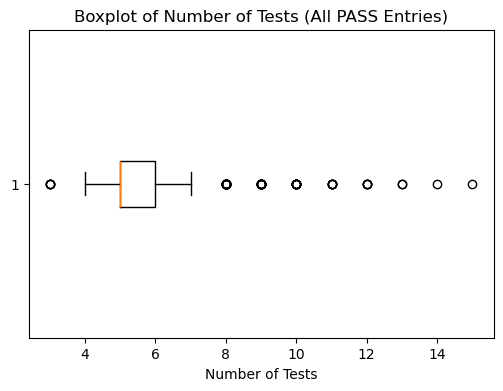

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


# 1. Load CSV

def load_csv(path):
    df = pd.read_csv(path)
    return df


# 2. Compute statistics

def compute_stats(df):
    stats = {
        "total_entries": len(df),
        "min_tests": df["num_tests"].min(),
        "max_tests": df["num_tests"].max(),
        "mean_tests": df["num_tests"].mean(),
        "median_tests": df["num_tests"].median(),
        "std_tests": df["num_tests"].std()
    }
    
    print("\n=== Statistics ===")
    for k, v in stats.items():
        print(f"{k}: {v}")
    
    return stats


# 3. Plot histogram

def plot_histogram(df):
    plt.figure(figsize=(8,5))
    plt.hist(df["num_tests"], bins=20, color="skyblue", edgecolor="black")
    plt.xlabel("Number of Tests per Entry")
    plt.ylabel("Frequency")
    plt.title("Distribution of Number of Tests (All PASS Entries)")
    plt.grid(axis="y", alpha=0.7)
    plt.show()


# 4. Plot boxplot

def plot_boxplot(df):
    plt.figure(figsize=(6,4))
    plt.boxplot(df["num_tests"], vert=False)
    plt.xlabel("Number of Tests")
    plt.title("Boxplot of Number of Tests (All PASS Entries)")
    plt.show()


# 5. Main

def main(csv_path):
    df = load_csv(csv_path)
    
    compute_stats(df)
    plot_histogram(df)
    plot_boxplot(df)

if __name__ == "__main__":
    main("../results/test_counts.csv")